# Week 05 Assessment — Exploratory Data Analysis

## Support Ticket Dataset

**Assessment:** Week 05 — EDA Practical + Theory Quiz  
**Part:** EDA Practical  
**Dataset:** Support Tickets  
**Objective:** Diagnose, clean, visualize, and summarize an intentionally imperfect dataset.

---

### Overview

This notebook presents a complete exploratory data analysis (EDA) workflow on a support-ticket dataset.

The analysis follows the complete data-analysis pipeline:

**Dataset Generation → Diagnosis → Cleaning → Verification → Visualization → Findings**

The dataset contains intentionally introduced data-quality issues, including missing values, inconsistent categories, invalid values, outliers, and duplicate records. The purpose of the assessment is to identify these problems independently, justify each cleaning decision, and produce evidence-backed analytical findings.

The original dataset is preserved throughout the analysis, while all cleaning operations are performed on a separate copy.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt


In [2]:


rng = np.random.default_rng(seed=7)
n = 4000

tickets = pd.DataFrame({
    "ticket_id": np.arange(1, n + 1),
    "created_at": pd.date_range("2024-03-01", periods=n, freq="30min"),
    "agent_id": rng.integers(200, 260, size=n),
    "priority": rng.choice(["Low", "Medium", "High", "high"], size=n),
    "resolution_hours": rng.gamma(shape=2.0, scale=6.0, size=n).round(2),
    "channel": rng.choice(
        ["Email", "Chat", "Phone", None],
        size=n,
        p=[0.35, 0.35, 0.25, 0.05]
    ),
})

tickets.loc[rng.choice(n, 120, replace=False), "agent_id"] = None
tickets.loc[rng.choice(n, 25, replace=False), "resolution_hours"] *= -1
tickets.loc[rng.choice(n, 15, replace=False), "resolution_hours"] = 999.0
tickets = pd.concat([tickets, tickets.sample(12, random_state=3)])

## 1. Dataset Generation

The support-ticket dataset is generated using the exact specification provided in the assessment.

The generation code is intentionally kept unchanged because the assessment requires every trainee to work with the same dataset and the same planted data-quality issues.

The generated dataset contains:

- `ticket_id` — unique identifier for each ticket
- `created_at` — ticket creation timestamp
- `agent_id` — identifier of the assigned support agent
- `priority` — ticket priority level
- `resolution_hours` — time taken to resolve the ticket
- `channel` — communication channel used to create the ticket

The dataset is expected to contain **4,012 rows and 6 columns**, including the intentionally added duplicate records.

In [3]:
assert tickets.shape == (4012, 6)
assert list(tickets.columns) == [
    "ticket_id",
    "created_at",
    "agent_id",
    "priority",
    "resolution_hours",
    "channel"
]

print("Setup confirmed — dataset matches spec.")

Setup confirmed — dataset matches spec.


### Dataset Structure Validation

Before beginning the analysis, the dataset structure is validated against the assessment specification.

The validation checks:

1. The expected number of rows and columns.
2. The exact column names and their order.

No data cleaning or modification is performed before this validation.

# 2. Diagnosis

The first stage of the EDA process is to understand the raw dataset before making any modifications.

No cleaning is performed during this stage. The purpose is to inspect the structure, data types, statistical characteristics, missing values, categorical distributions, and potential data-quality problems.

The following diagnostic methods are used:

- `.head()` to inspect representative records.
- `.info()` to inspect data types and non-null counts.
- `.describe()` to examine numerical statistics.
- `.isna().sum()` to identify missing values.
- `.value_counts()` to examine categorical distributions.
- Additional targeted checks to identify invalid values, outliers, and duplicate records.

### 2.1 Initial Dataset Inspection

The first few records are inspected to understand the structure and contents of the dataset before performing any transformation.

In [4]:
tickets.head()

,ticket_id,created_at,agent_id,priority,resolution_hours,channel
0,1,2024-03-01 00:00:00,256.0,High,4.20,Email
1,2,2024-03-01 00:30:00,237.0,Low,13.49,Chat
2,3,2024-03-01 01:00:00,241.0,high,6.97,Email
3,4,2024-03-01 01:30:00,253.0,Medium,4.90,Chat
4,5,2024-03-01 02:00:00,234.0,Medium,5.60,Email


### 2.2 Dataset Information

The `.info()` output is used to examine the dataset's column types, number of non-null values, and overall memory structure.

This is particularly useful for identifying columns containing missing values and checking whether the data types are appropriate for analysis.

In [5]:
tickets.info()

<class 'pandas.DataFrame'>
Index: 4012 entries, 0 to 1707
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticket_id         4012 non-null   int64         
 1   created_at        4012 non-null   datetime64[us]
 2   agent_id          3891 non-null   float64       
 3   priority          4012 non-null   str           
 4   resolution_hours  4012 non-null   float64       
 5   channel           3819 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 219.4 KB


### 2.3 Descriptive Statistics

Descriptive statistics are examined for the numerical columns to understand their central tendency, spread, and range.

These statistics also help identify values that may require further investigation, particularly unusually large or negative resolution times.

In [6]:
tickets.describe()

,ticket_id,created_at,agent_id,resolution_hours
count,4012.000000,4012,3891.000000,4012.000000
mean,2001.531406,2024-04-11 16:15:56.530408,229.814701,15.561725
min,1.000000,2024-03-01 00:00:00,200.000000,-37.810000
25%,1002.750000,2024-03-21 20:52:30,215.000000,5.700000
50%,2000.500000,2024-04-11 15:45:00,229.000000,10.180000
75%,3002.250000,2024-05-02 12:37:30,245.000000,16.242500
max,4000.000000,2024-05-23 07:30:00,259.000000,999.000000
std,1154.879052,NaN,17.141925,60.867741


### 2.4 Missing-Value Analysis

Missing values are examined column by column.

The goal at this stage is not to immediately remove or replace missing values, but to understand where they occur and determine the appropriate treatment during the cleaning stage.

In [7]:
tickets.isna().sum()

ticket_id             0
created_at            0
agent_id            121
priority              0
resolution_hours      0
channel             193
dtype: int64

### 2.5 Categorical Analysis

Categorical columns are examined using frequency counts.

This helps identify both expected categories and potential inconsistencies in category representation, such as different capitalization being used for the same logical category.

In [8]:
tickets["priority"].value_counts(dropna=False)

priority
Medium    1019
Low       1011
High      1000
high       982
Name: count, dtype: int64

In [9]:
tickets["channel"].value_counts(dropna=False)

channel
Chat     1411
Email    1382
Phone    1026
NaN       193
Name: count, dtype: int64

### 2.6 Additional Data-Quality Checks

The dataset is inspected more critically for problems that cannot be identified through missing-value analysis alone.

The following checks are performed:

- Negative resolution durations
- Extreme resolution-time values
- Duplicate records
- Inconsistent priority categories

These checks are important because a dataset can contain complete values while still containing incorrect or misleading records.

In [10]:
(tickets["resolution_hours"] < 0).sum()

np.int64(25)

In [11]:
(tickets["resolution_hours"] == 999.0).sum()

np.int64(15)

In [12]:
tickets.duplicated().sum()

np.int64(12)

In [13]:
tickets["priority"].unique()

<StringArray>
['High', 'Low', 'high', 'Medium']
Length: 4, dtype: str

In [14]:
missing_agent_id = int(tickets["agent_id"].isna().sum())

missing_channel = int(tickets["channel"].isna().sum())

duplicate_rows = int(tickets.duplicated().sum())

negative_resolution_hours = int(
    (tickets["resolution_hours"] < 0).sum()
)

outlier_resolution_hours = int(
    (tickets["resolution_hours"] == 999.0).sum()
)

print("Missing agent_id:", missing_agent_id)
print("Missing channel:", missing_channel)
print("Duplicate rows:", duplicate_rows)
print("Negative resolution hours:", negative_resolution_hours)
print("Outlier resolution hours:", outlier_resolution_hours)

Missing agent_id: 121
Missing channel: 193
Duplicate rows: 12
Negative resolution hours: 25
Outlier resolution hours: 15


## 2.7 Diagnosis Findings

The raw dataset contains multiple data-quality issues that were identified before any cleaning was performed.

The diagnosis found:

- **121 missing `agent_id` values**
- **193 missing `channel` values**
- **12 duplicate rows**
- **25 negative `resolution_hours` values**
- **15 extreme `resolution_hours` values of 999 hours**
- Inconsistent capitalization in the `priority` column, where `High` and `high` represent the same logical category.

These issues are treated separately during the cleaning stage. No blanket cleaning operation is applied because different types of data-quality problems require different decisions.

# 3. Data Cleaning

The cleaning stage is performed on a copy of the raw dataset so that the original dataset remains available for inspection and comparison.

Each data-quality issue is handled separately based on the meaning of the affected column and the nature of the problem.

The objective is not simply to remove problematic rows, but to preserve as much useful information as possible while avoiding unsupported assumptions.

In [15]:
tickets_clean = tickets.copy()

In [16]:
print("Raw shape:", tickets.shape)
print("Cleaning copy shape:", tickets_clean.shape)

Raw shape: (4012, 6)
Cleaning copy shape: (4012, 6)


### 3.1 Handling Missing `agent_id`

**Decision:** Remove rows with missing `agent_id`.

An agent ID is an entity identifier, and the responsible agent cannot be reliably inferred from the other available columns. Filling the missing identifier with an arbitrary value would create a false agent assignment.

Therefore, rows with missing `agent_id` values are removed.

In [17]:
tickets_clean = tickets_clean.dropna(subset=["agent_id"])

### 3.2 Handling Missing `channel`

**Decision:** Replace missing values with `Unknown`.

A ticket remains useful for analysis even when its communication channel is unavailable. Removing these records would unnecessarily discard valid ticket information.

Because the actual channel cannot be reliably inferred, the missing values are explicitly represented as `Unknown` rather than assigning an unsupported channel.

In [18]:
tickets_clean["channel"] = tickets_clean["channel"].fillna("Unknown")

In [19]:
tickets_clean["priority"] = tickets_clean["priority"].str.title()

### 3.3 `priority` Cleaning Decision

Priority labels are standardized using consistent capitalization so that `High` and `high` are treated as the same category rather than being counted separately.

In [20]:
tickets_clean = tickets_clean[
    tickets_clean["resolution_hours"] >= 0
].copy()

### 3.4 `resolution_hours` — Negative Values

Negative resolution durations are removed because a standard ticket resolution time cannot be negative and the correct value cannot be reliably reconstructed from the available data.

In [21]:
resolution_median = tickets_clean.loc[
    tickets_clean["resolution_hours"] != 999.0,
    "resolution_hours"
].median()

print("Median resolution hours:", resolution_median)

Median resolution hours: 10.24


In [22]:
tickets_clean.loc[
    tickets_clean["resolution_hours"] == 999.0,
    "resolution_hours"
] = resolution_median

### 3.5 `resolution_hours` — Extreme Outliers

The 999-hour values are treated as data-entry outliers because they are implausibly large compared with the normal resolution-time distribution. Instead of removing these tickets, the outlier values are replaced with the median of the valid resolution times. The median is preferred because resolution times are right-skewed and the median is less sensitive to extreme values than the mean.

In [23]:
print(
    "Remaining 999-hour values:",
    (tickets_clean["resolution_hours"] == 999.0).sum()
)

Remaining 999-hour values: 0


In [24]:
tickets_clean = tickets_clean.drop_duplicates().copy()

### 3.6 Duplicate Rows

Exact duplicate records are removed because they represent repeated copies of the same ticket record and would otherwise cause the same observation to be counted more than once.

In [25]:
print("Raw dataset shape:", tickets.shape)
print("Cleaned dataset shape:", tickets_clean.shape)

print("\nMissing values:")
print(tickets_clean.isna().sum())

print("\nDuplicate rows:", tickets_clean.duplicated().sum())
print("Negative resolution hours:", (tickets_clean["resolution_hours"] < 0).sum())
print("999-hour outliers:", (tickets_clean["resolution_hours"] == 999.0).sum())
print("\nPriority categories:")
print(tickets_clean["priority"].value_counts())

Raw dataset shape: (4012, 6)
Cleaned dataset shape: (3856, 6)

Missing values:
ticket_id           0
created_at          0
agent_id            0
priority            0
resolution_hours    0
channel             0
dtype: int64

Duplicate rows: 0
Negative resolution hours: 0
999-hour outliers: 0

Priority categories:
priority
High      1912
Medium     980
Low        964
Name: count, dtype: int64


## 3.7 Cleaning Verification

After applying the cleaning decisions, the cleaned dataset is checked again to confirm that the identified data-quality issues have been addressed.

The verification checks:

- Remaining missing values
- Remaining duplicate records
- Remaining negative resolution times
- Remaining 999-hour outliers
- Standardized priority categories
- Final dataset dimensions

The original `tickets` DataFrame remains unchanged, while `tickets_clean` contains the cleaned data used for subsequent analysis.

## 3.8 Exporting the Cleaned Dataset and Diagnosis Results

The cleaned dataset is exported as `tickets_clean.csv`.

The original diagnosis results are exported separately as `findings.json`. These findings are calculated from the raw dataset before cleaning, as required by the assessment.

The exported files provide reproducible outputs that can be checked independently of the notebook execution.

In [26]:
tickets_clean.to_csv("tickets_clean.csv", index=False)

In [27]:

print("tickets_clean.csv exists:", Path("tickets_clean.csv").exists())

tickets_clean.csv exists: True


In [28]:

findings = {
    "missing_agent_id": int(tickets["agent_id"].isna().sum()),
    "missing_channel": int(tickets["channel"].isna().sum()),
    "duplicate_rows": int(tickets.duplicated().sum()),
    "negative_resolution_hours": int(
        (tickets["resolution_hours"] < 0).sum()
    ),
    "outlier_resolution_hours": int(
        (tickets["resolution_hours"] == 999.0).sum()
    ),
}

with open("findings.json", "w") as f:
    json.dump(findings, f)

In [29]:
print(findings)

{'missing_agent_id': 121, 'missing_channel': 193, 'duplicate_rows': 12, 'negative_resolution_hours': 25, 'outlier_resolution_hours': 15}


In [30]:
check_df = pd.read_csv("tickets_clean.csv")
check_findings = json.loads(Path("findings.json").read_text())

print("CSV shape:", check_df.shape)
print("CSV columns:", list(check_df.columns))
print("Findings:", check_findings)

CSV shape: (3856, 6)
CSV columns: ['ticket_id', 'created_at', 'agent_id', 'priority', 'resolution_hours', 'channel']
Findings: {'missing_agent_id': 121, 'missing_channel': 193, 'duplicate_rows': 12, 'negative_resolution_hours': 25, 'outlier_resolution_hours': 15}


# 4. Visualization

Visualization is used to communicate patterns in the cleaned dataset.

Each chart is selected based on the specific analytical question it is intended to answer:

1. **Distribution:** How are ticket resolution times distributed?
2. **Category comparison:** How does average resolution time differ across priority categories?
3. **Relationship:** Is there an observable relationship between ticket ID and resolution time?

All charts are created using `fig, ax = plt.subplots()` and include appropriate titles and axis labels.

## 4.1 Resolution-Time Distribution

### Question

**How are ticket resolution times distributed after cleaning?**

A histogram is appropriate because `resolution_hours` is a numerical variable and the purpose of this visualization is to understand its distribution, concentration, and spread.

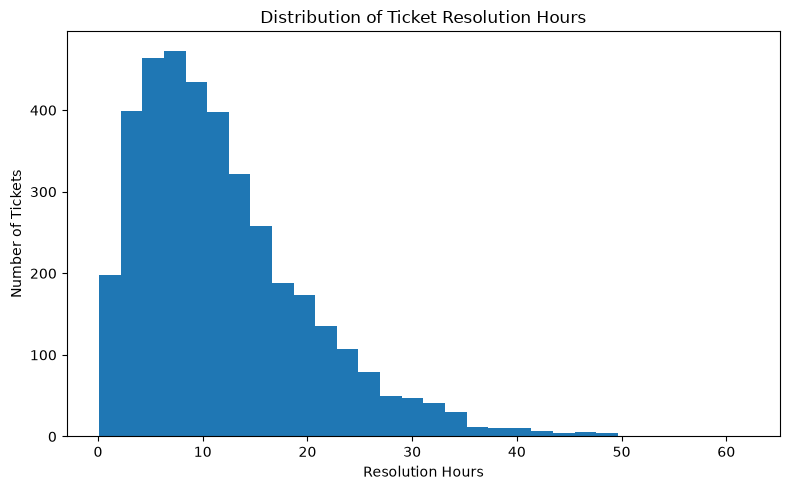

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    tickets_clean["resolution_hours"],
    bins=30
)

ax.set_title("Distribution of Ticket Resolution Hours")
ax.set_xlabel("Resolution Hours")
ax.set_ylabel("Number of Tickets")

fig.tight_layout()
fig.savefig("chart_distribution.png")
plt.show()

In [32]:
chart_path = Path("chart_distribution.png")

print("Exists:", chart_path.exists())
print("Size:", chart_path.stat().st_size if chart_path.exists() else 0)

Exists: True
Size: 15761


In [33]:
priority_avg_resolution = (
    tickets_clean
    .groupby("priority")["resolution_hours"]
    .mean()
)

priority_avg_resolution

priority
High      12.127835
Low       12.191732
Medium    11.703429
Name: resolution_hours, dtype: float64

## 4.2 Average Resolution Time by Priority

### Question

**How does average resolution time differ across ticket priority levels?**

A bar chart is used because priority levels are discrete categories. The chart allows the average resolution time of each category to be compared directly.

A line chart would imply a continuous or sequential relationship between the categories, which is not appropriate for these discrete priority groups.

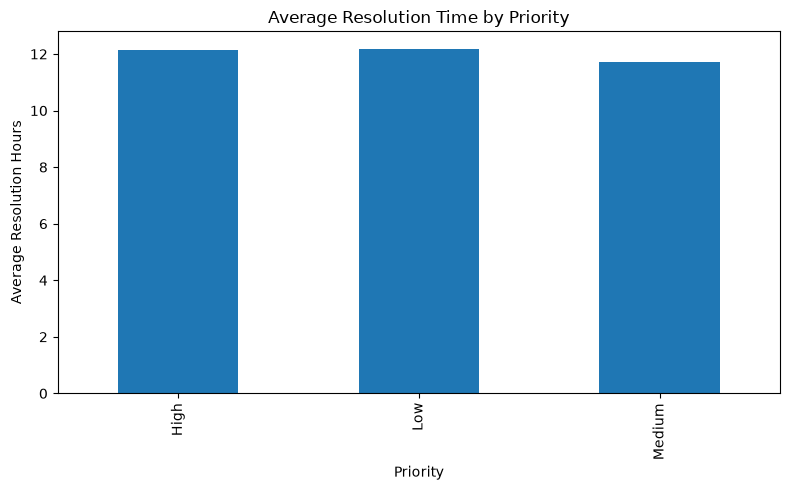

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

priority_avg_resolution.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Average Resolution Time by Priority")
ax.set_xlabel("Priority")
ax.set_ylabel("Average Resolution Hours")

fig.tight_layout()
fig.savefig("chart_category_comparison.png")
plt.show()

In [35]:
chart_path = Path("chart_category_comparison.png")

print("Exists:", chart_path.exists())
print("Size:", chart_path.stat().st_size if chart_path.exists() else 0)

Exists: True
Size: 16441


## 4.3 Ticket ID and Resolution-Time Relationship

### Question

**Is there an observable relationship between ticket ID and resolution time?**

A scatter plot is used because the analysis examines the relationship between two numerical variables: `ticket_id` and `resolution_hours`.

The scatter plot allows us to visually inspect whether resolution time changes systematically with ticket ID.

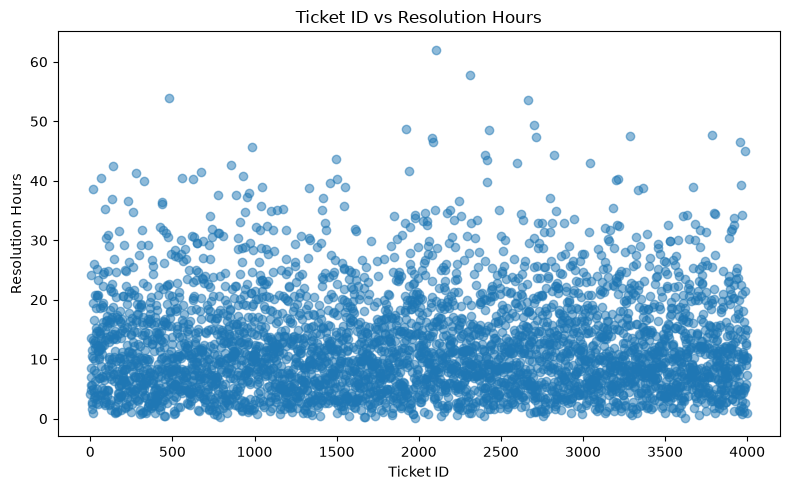

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    tickets_clean["ticket_id"],
    tickets_clean["resolution_hours"],
    alpha=0.5
)

ax.set_title("Ticket ID vs Resolution Hours")
ax.set_xlabel("Ticket ID")
ax.set_ylabel("Resolution Hours")

fig.tight_layout()
fig.savefig("chart_relationship.png")
plt.show()

In [37]:
chart_path = Path("chart_relationship.png")

print("Exists:", chart_path.exists())
print("Size:", chart_path.stat().st_size if chart_path.exists() else 0)

Exists: True
Size: 191396


In [38]:
print("Overall mean resolution:",
      tickets_clean["resolution_hours"].mean())

print("\nAverage resolution by priority:")
print(priority_avg_resolution)

print("\nMedian resolution:",
      tickets_clean["resolution_hours"].median())

print("\nMinimum resolution:",
      tickets_clean["resolution_hours"].min())

print("\nMaximum resolution:",
      tickets_clean["resolution_hours"].max())

Overall mean resolution: 12.035946576763486

Average resolution by priority:
priority
High      12.127835
Low       12.191732
Medium    11.703429
Name: resolution_hours, dtype: float64

Median resolution: 10.24

Minimum resolution: 0.1

Maximum resolution: 62.03


# 5. Findings

The following findings summarize the main patterns identified from the cleaned dataset.

Each finding is supported by a specific numerical result or visualization rather than being based only on expectations about the dataset.

## 5.1 Key Findings

### Finding 1 — Overall Resolution Time

The cleaned dataset has an average ticket resolution time of approximately **12.04 hours**, while the median is **10.24 hours**. The difference between the mean and median indicates that the resolution-time distribution is somewhat right-skewed, with some tickets taking substantially longer than the typical ticket.

### Finding 2 — Resolution Time by Priority

Average resolution time differs across priority levels. **Low-priority tickets have the highest average resolution time at approximately 12.19 hours**, followed by High at approximately 12.13 hours and Medium at approximately 11.70 hours.

### Finding 3 — Resolution-Time Range

After cleaning, resolution times range from **0.10 to 62.03 hours**. The distribution chart shows that most observations are concentrated toward the lower resolution-time range, while a smaller number of tickets require substantially more time to resolve.

# 6. Technical Summary

The support-ticket dataset contains information about ticket identifiers, creation timestamps, assigned agents, priority levels, resolution durations, and communication channels.

The raw dataset contained several data-quality issues, including missing agent and channel information, inconsistent priority capitalization, negative resolution durations, extreme 999-hour values, and duplicate records.

Each issue was handled independently. Missing agent IDs were removed because the responsible agent could not be reliably inferred. Missing channels were represented as `Unknown` to preserve otherwise useful tickets. Priority categories were standardized, negative resolution times were removed, 999-hour outliers were replaced using the median of valid resolution times, and duplicate rows were removed.

The cleaned dataset has an average resolution time of approximately 12.04 hours and a median of 10.24 hours. Low-priority tickets have the highest average resolution time among the three priority categories, at approximately 12.19 hours.

### Limitation

The dataset is artificially generated for assessment purposes and may not represent real-world support-ticket behavior. Additionally, variables such as issue complexity, agent experience, ticket subject, and customer characteristics are not available, so the analysis cannot determine the underlying causes of differences in resolution time.

# 7. Reproducibility and Validation

The assessment outputs were saved using the exact filenames required by the specification:

- `tickets_clean.csv`
- `findings.json`
- `chart_distribution.png`
- `chart_category_comparison.png`
- `chart_relationship.png`

The provided sample test was used to verify the required output structure.

Finally, the notebook should be tested using:

**Restart Kernel → Run All**

This ensures that the notebook does not depend on hidden kernel state or previously executed cells and that the complete analysis can be reproduced from top to bottom.

# 8. Conclusion

This assessment demonstrated a complete exploratory data analysis workflow on an intentionally imperfect support-ticket dataset.

The analysis began with diagnosis of the raw data, followed by issue-specific cleaning decisions, verification of the cleaned dataset, targeted visualization, and evidence-based interpretation.

The workflow also demonstrates the importance of preserving raw data, documenting cleaning decisions, exporting reproducible outputs, and validating the final notebook before submission.